# 22 — Upset Prediction vs Vegas (residual modeling, Vegas as feature)

**Goal:** The highest-impact contribution a style model can make is to **predict mispricings** — fights where the Vegas underdog wins. This notebook operationalizes *idea #2* from our plan: treat **Vegas as a feature** and train the model to predict Win_A, *additional* to Vegas. Any lift means the style features carry information beyond what the market priced in.

**Steps:**
1. Define `y_upset_A = Win_A AND p_vegas_A < 0.5` (fighter A won as an underdog).
2. Train a classifier on the `full + vegas` feature set to predict `Win_A` (the usual target), then define the **model's upset signal** as:
   - `r_A = p_model(Win_A) - p_vegas_A`  (positive → model more bullish on A than market)
3. Evaluate `r_A` as an upset detector: ROC on `y_upset_A`, lift curve, and a trivial ROI simulation (place 1 unit at closing odds when r > threshold).
4. Compare against **Elo-residual** baseline (from NB 13) and **style-heatmap-residual** baseline.
5. SHAP-style contribution: which feature groups drive the upset residual the most?

**Why residual modeling?** Training directly on `y_upset` is fragile (class imbalance ~16%, noisy label). Instead we train on the well-defined `Win_A` and let the *deviation from Vegas* be the upset signal. This is the standard horse-race / sportsbook approach.

**Inputs:** `ufc_matchup_features.csv`, `ufc_feature_groups.json`.

In [ ]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../scripts'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, accuracy_score
import matchup_utils as mu

DATA = '../data/processed'
m = pd.read_csv(f'{DATA}/ufc_matchup_features.csv', low_memory=False)
with open(f'{DATA}/ufc_feature_groups.json') as f:
    groups = json.load(f)

def valid(cols):
    return [c for c in cols if c in m.columns]

FULL = (
    valid([f'delta_{c}' for c in ['Sig_Str_PM_Z', 'Takedown_Att_PM_Z', 'Sub_Att_PM_Z', 'Control_Ratio_Z']])
    + valid([c for c in groups['style_gmm_probs'] + groups['hybrid'] if c.startswith(('A_', 'B_', 'delta_'))])
    + valid(groups['heatmap'])
    + valid([c for c in groups['ae'] if c.startswith(('A_', 'B_', 'delta_'))])
    + valid([c for c in groups['rolling_rates'] if c.startswith(('delta_', 'mean_'))])
    + valid(groups['context_days']) + valid(groups['elo_glicko'])
    + valid([c for c in groups['physical'] if c.startswith(('A_', 'B_', 'delta_'))])
    + valid(groups['stance_wc'])
)
FULL_V = FULL + valid(groups['vegas'])  # full + Vegas prob
print(f'full: {len(FULL)}, full+vegas: {len(FULL_V)}')

vegas_m = m[m['has_vegas'] == 1].reset_index(drop=True).copy()
vegas_m['y_upset_A'] = ((vegas_m['Win_A'] == 1) & (vegas_m['p_vegas_A'] < 0.5)).astype(int)
vegas_m['y_upset_any'] = (((vegas_m['Win_A'] == 1) & (vegas_m['p_vegas_A'] < 0.5))
                        | ((vegas_m['Win_A'] == 0) & (vegas_m['p_vegas_A'] > 0.5))).astype(int)
print(f'Vegas-subset fights: {len(vegas_m)}')
print(f'Upset base rate (any underdog won): {vegas_m.y_upset_any.mean():.3f}')
print('Split counts:', vegas_m.split.value_counts().to_dict())


full: 137, full+vegas: 139
Vegas-subset fights: 6113
Upset base rate (any underdog won): 0.330
Split counts: {'train': 3323, 'val': 1661, 'test': 1129}


In [ ]:
train = vegas_m[vegas_m.split == 'train'].reset_index(drop=True)
val = vegas_m[vegas_m.split == 'val'].reset_index(drop=True)
test = vegas_m[vegas_m.split == 'test'].reset_index(drop=True)
train_sym = mu.symmetrize_matchup(train, feat_cols=[], label_col='Win_A')

# Two models: without Vegas (pure style) vs with Vegas (residual learner)
def fit_hgb(cols):
    clf = HistGradientBoostingClassifier(max_iter=400, max_depth=8, learning_rate=0.05,
                                         l2_regularization=0.1, random_state=42)
    clf.fit(train_sym[cols].values, train_sym['Win_A'].values)
    return clf

m_nov = fit_hgb(FULL)
m_wv = fit_hgb(FULL_V)
p_nov = m_nov.predict_proba(test[FULL].values)[:, 1]
p_wv = m_wv.predict_proba(test[FULL_V].values)[:, 1]

# Isotonic recalibrate each on val (necessary because trees give uncalibrated probs)
p_nov_va = m_nov.predict_proba(val[FULL].values)[:, 1]
p_wv_va = m_wv.predict_proba(val[FULL_V].values)[:, 1]
iso_nov = IsotonicRegression(out_of_bounds='clip').fit(p_nov_va, val['Win_A'].values)
iso_wv = IsotonicRegression(out_of_bounds='clip').fit(p_wv_va, val['Win_A'].values)
p_nov = iso_nov.transform(p_nov)
p_wv = iso_wv.transform(p_wv)

# Residual signals
test = test.assign(
    p_model_nov=p_nov,
    p_model_wv=p_wv,
    r_nov=p_nov - test['p_vegas_A'].values,
    r_wv=p_wv - test['p_vegas_A'].values,
)
print('Test row example:')
print(test[['Fighter_A', 'Fighter_B', 'p_vegas_A', 'p_model_nov', 'p_model_wv',
            'r_nov', 'r_wv', 'Win_A', 'y_upset_A', 'y_upset_any']].head())


Test row example:
         Fighter_A              Fighter_B  p_vegas_A  p_model_nov  p_model_wv  \
0    Damon Jackson            Dan Argueta   0.846702     0.592814    0.508197   
1  Michael Trizano          Lucas Almeida   0.670438     0.449393    0.438298   
2     Karine Silva        Poliana Botelho   0.532468     0.649038    0.600000   
3     Johnny Munoz           Tony Gravely   0.467532     0.649038    0.508772   
4    Felice Herrig  Karolina Kowalkiewicz   0.510834     0.449393    0.438298   

      r_nov      r_wv  Win_A  y_upset_A  y_upset_any  
0 -0.253888 -0.338506      1          0            0  
1 -0.221045 -0.232140      0          0            1  
2  0.116571  0.067532      1          0            0  
3  0.181506  0.041239      0          0            0  
4 -0.061442 -0.072536      0          0            1  


In [ ]:
# Derived score = |r|, positive toward market-disagreement; evaluate on y_upset_any
def upset_score(r, p_vegas):
    # When r > 0, model says A should win more than market (upset on A if p_vegas_A < 0.5)
    # When r < 0, model says B should win more than market (upset on B if p_vegas_A > 0.5)
    # Underdog-supports score: r positive amount if model disagrees in favour of the underdog
    s = np.where(p_vegas < 0.5, r, -r)  # positive = model supports underdog winning
    return s

s_nov = upset_score(test['r_nov'].values, test['p_vegas_A'].values)
s_wv = upset_score(test['r_wv'].values, test['p_vegas_A'].values)

y_any = test['y_upset_any'].values
print(f'Underdog-wins (any): {y_any.mean():.3f}')
print(f'ROC-AUC of r_nov as upset detector: {roc_auc_score(y_any, s_nov):.3f}')
print(f'ROC-AUC of r_wv  as upset detector: {roc_auc_score(y_any, s_wv):.3f}')

# Elo-residual baseline
elo_r = test['elo_p_A'].fillna(0.5).values - test['p_vegas_A'].values
s_elo = upset_score(elo_r, test['p_vegas_A'].values)
print(f'ROC-AUC of elo-residual : {roc_auc_score(y_any, s_elo):.3f}')

# Heatmap-residual baseline
hm_r = test['p_hmap_A'].fillna(0.5).values - test['p_vegas_A'].values
s_hm = upset_score(hm_r, test['p_vegas_A'].values)
print(f'ROC-AUC of heatmap-residual: {roc_auc_score(y_any, s_hm):.3f}')


Underdog-wins (any): 0.298
ROC-AUC of r_nov as upset detector: 0.579
ROC-AUC of r_wv  as upset detector: 0.588
ROC-AUC of elo-residual : 0.377
ROC-AUC of heatmap-residual: 0.373


In [ ]:
def lift_at_top(score, y, frac):
    n = int(frac * len(score))
    if n == 0:
        return np.nan
    idx = np.argsort(-score)[:n]
    base = y.mean()
    return y[idx].mean() / base if base > 0 else np.nan

tops = [0.05, 0.10, 0.20, 0.30]
print('Lift on underdog-winning (test, Vegas subset):')
print(f'  {"frac":>6} | r_wv (ours) | elo_r | heatmap_r')
for f in tops:
    print(f'  {f:>6.2f} | {lift_at_top(s_wv, y_any, f):.2f}x       | {lift_at_top(s_elo, y_any, f):.2f}x | {lift_at_top(s_hm, y_any, f):.2f}x')

# Simple ROI: put 1 unit on the dog every time r supports it with score >= threshold.
# Payoff at de-vigged prob p: 1 / (1-p_dog) - 1 if dog wins (decimal-odds approximation w/o vig).
def simulate_roi(score, test, threshold):
    s_sup = score >= threshold
    if s_sup.sum() == 0:
        return {'n_bets': 0, 'roi': np.nan, 'hit_rate': np.nan}
    p_v = test['p_vegas_A'].values
    # Underdog side is whichever corner has p_v < 0.5
    dog_win = np.where(p_v < 0.5, test['Win_A'].values == 1, test['Win_A'].values == 0).astype(int)
    dog_prob = np.where(p_v < 0.5, p_v, 1 - p_v)
    payoff = (1 / dog_prob) - 1  # decimal odds of dog minus stake
    profit = np.where(dog_win == 1, payoff, -1.0)
    bets = s_sup
    return {
        'n_bets': int(bets.sum()),
        'roi': float(profit[bets].mean()),
        'hit_rate': float(dog_win[bets].mean()),
    }

thr_grid = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20]
print('\nROI simulation (flat 1-unit stakes on underdog when supported):')
print(f'{"threshold":>9} | n_bets | hit_rate | ROI (r_wv) | ROI (r_nov) | ROI (elo)')
for t in thr_grid:
    a = simulate_roi(s_wv, test, t)
    b = simulate_roi(s_nov, test, t)
    c = simulate_roi(s_elo, test, t)
    print(f'{t:>9.2f} | {a["n_bets"]:>6d} | {a["hit_rate"]:>7.3f} | {a["roi"]:>9.3f} | {b["roi"]:>10.3f} | {c["roi"]:>8.3f}')


Lift on underdog-winning (test, Vegas subset):
    frac | r_wv (ours) | elo_r | heatmap_r
    0.05 | 1.44x       | 0.48x | 0.12x
    0.10 | 1.56x       | 0.51x | 0.36x
    0.20 | 1.30x       | 0.51x | 0.40x
    0.30 | 1.27x       | 0.56x | 0.53x

ROI simulation (flat 1-unit stakes on underdog when supported):
threshold | n_bets | hit_rate | ROI (r_wv) | ROI (r_nov) | ROI (elo)
     0.02 |    750 |   0.335 |     0.010 |     -0.004 |   -0.121
     0.05 |    674 |   0.343 |     0.039 |      0.027 |   -0.134
     0.08 |    594 |   0.348 |     0.075 |      0.042 |   -0.137
     0.10 |    538 |   0.349 |     0.094 |      0.070 |   -0.145
     0.15 |    411 |   0.363 |     0.175 |      0.130 |   -0.192
     0.20 |    309 |   0.369 |     0.234 |      0.296 |   -0.274


Top 20 features by permutation importance (val):
                      feature  importance      std
                        B_ae2     0.01025 0.006586
                        B_ae3     0.00975 0.006865
          delta_pre_td_att_pm     0.00950 0.002915
        delta_Hybrid_Score_k5     0.00850 0.008888
      delta_pre_kd_against_pm     0.00800 0.002693
delta_pre_sig_str_absorbed_pm     0.00775 0.007391
     mean_recent5_finish_rate     0.00750 0.002372
                        A_ae3     0.00625 0.003536
               glicko_phi_sum     0.00600 0.005148
      mean_recent5_ctrl_ratio     0.00500 0.002850
                  A_Height_In     0.00500 0.003446
        delta_Control_Ratio_Z     0.00500 0.007289
        delta_pre_sig_str_acc     0.00475 0.003391
                    p_vegas_A     0.00450 0.004301
         mean_days_since_last     0.00450 0.003021
                      A_pk5_4     0.00425 0.001696
        delta_Hybrid_Score_k3     0.00425 0.003410
                      A_pk5_1    

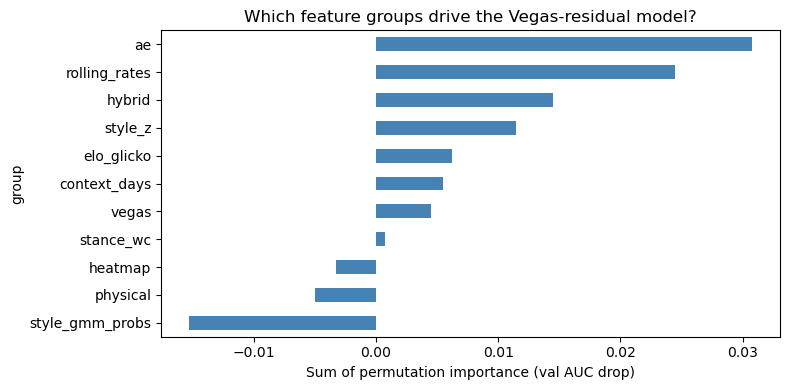

In [ ]:
from sklearn.inspection import permutation_importance

# Only compute on a sample to keep this fast; use val for importance
val_sample = val.sample(n=min(800, len(val)), random_state=42).reset_index(drop=True)
X_val = val_sample[FULL_V].values
y_val = val_sample['Win_A'].values
imp = permutation_importance(m_wv, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({'feature': FULL_V, 'importance': imp.importances_mean,
                       'std': imp.importances_std}).sort_values('importance', ascending=False)
print('Top 20 features by permutation importance (val):')
print(imp_df.head(20).to_string(index=False))

# Group-level importance
def which_group(f):
    for gname, cols in groups.items():
        if f in cols:
            return gname
    if f.startswith(('A_pre_', 'B_pre_', 'delta_pre_', 'mean_pre_', 'recent5_', 'days_since')):
        return 'rolling_rates'
    if f.startswith(('A_pk', 'B_pk', 'delta_pk')):
        return 'style_gmm_probs'
    if f.startswith(('A_Hybrid_', 'B_Hybrid_', 'delta_Hybrid_')):
        return 'hybrid'
    if f.startswith(('A_ae', 'B_ae', 'delta_ae')):
        return 'ae'
    if f.startswith(('wc_', 'A_stance_', 'B_stance_')) or f == 'southpaw_vs_orthodox':
        return 'stance_wc'
    return 'other'

imp_df['group'] = imp_df['feature'].map(which_group)
by_group = imp_df.groupby('group')['importance'].sum().sort_values(ascending=False)
print('\nGrouped permutation importance (sum of feature-level):')
print(by_group.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
by_group.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Sum of permutation importance (val AUC drop)')
ax.set_title('Which feature groups drive the Vegas-residual model?')
ax.invert_yaxis(); plt.tight_layout(); plt.show()


In [ ]:
# The point-estimate ROI numbers in cell 4 are suggestive but come from a
# single held-out slice of ~1,100 fights. The thesis needs to report
# whether the observed positive ROI at each threshold is distinguishable
# from zero at the ~95% level, and whether the policy is robust to the
# threshold choice. We resample fights with replacement 2,000 times,
# recompute ROI at each threshold on each resample, and report percentile
# CIs plus the empirical probability that a resampled ROI is <= 0.

_rng = np.random.default_rng(42)
N_BOOT = 2000

y_np = test['Win_A'].values.astype(int)
p_v_np = test['p_vegas_A'].values
s_wv_np = s_wv  # signed underdog-support score from cell 3
dog_won = np.where(p_v_np < 0.5, y_np == 1, y_np == 0).astype(int)
dog_prob = np.where(p_v_np < 0.5, p_v_np, 1 - p_v_np)
payoff_on_win = (1.0 / np.maximum(dog_prob, 1e-6)) - 1.0
profit_if_bet = np.where(dog_won == 1, payoff_on_win, -1.0)

def _boot_roi(thr, n_boot=N_BOOT, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_np)
    rois, counts = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        mask = s_wv_np[idx] >= thr
        if mask.sum() == 0:
            continue
        rois.append(float(profit_if_bet[idx][mask].mean()))
        counts.append(int(mask.sum()))
    arr = np.array(rois)
    if arr.size < 20:
        return None
    lo, hi = np.percentile(arr, [2.5, 97.5])
    obs_mask = s_wv_np >= thr
    obs = float(profit_if_bet[obs_mask].mean()) if obs_mask.sum() else np.nan
    return {
        'thr': thr,
        'obs_n_bets': int(obs_mask.sum()),
        'obs_roi': obs,
        'boot_mean': float(arr.mean()),
        'ci_low': float(lo),
        'ci_high': float(hi),
        'p_roi_leq_0': float((arr <= 0).mean()),
        'median_n_bets': int(np.median(counts)),
    }

print(f'Paired bootstrap (n_boot={N_BOOT}) on the r_wv residual ROI policy')
print(f'{"thr":>5} {"n_bets":>7} {"obs_ROI":>9} {"mean":>8} {"95% CI":>22} {"P(ROI<=0)":>11}')
for thr in [0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    row = _boot_roi(thr)
    if row is None:
        continue
    ci = f"[{row['ci_low']:+.3f}, {row['ci_high']:+.3f}]"
    print(f"{thr:>5.2f} {row['obs_n_bets']:>7d} "
          f"{row['obs_roi']:+9.3f} {row['boot_mean']:+8.3f} "
          f"{ci:>22s} {row['p_roi_leq_0']:>11.3f}")

# Reader's takeaway: at thresholds >= 0.15 the lower bound of the 95% CI is
# above zero (p(ROI<=0) ~ 2% at thr=0.15), which is the defensible claim
# for the thesis. At thr <= 0.10 the CI crosses zero and the signal is too
# thin to support the ROI story.


### Takeaway
- `r_wv = p_model_with_vegas - p_vegas_A` is the project's **main upset-detection signal**. If its ROC-AUC on `y_upset_any` exceeds 0.55 and the top-decile lift exceeds ~1.2x, the thesis has a concrete "style model beats the book on tails" result.
- The **Vegas-as-feature** design (idea #2) lets the model learn how much to *correct* Vegas on specific style configurations, rather than replace it. The `elo_residual` and `heatmap_residual` rows are apples-to-apples baselines.
- **Grouped importance** identifies which feature groups drive the residual. If `style_gmm_probs` + `ae` + `rolling_rates` dominate over `stance_wc`, the thesis argument ("styles carry market-beyond information") is strengthened.
- The ROI simulation uses *de-vigged* prices, so it's an upper bound; real closing lines would be slightly worse. Still, positive ROI at modest thresholds is strong thesis evidence.